In [19]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")

In [2]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
FEATURE_DIR = DATA_DIR / "features"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

advanced_features_path = FEATURE_DIR / "ptb_detection_advanced_fiducial_features.csv"
old_features_with_split_path = FEATURE_DIR / "ptb_detection_handcrafted_features_with_split.csv"
patient_split_path = PROCESSED_DIR / "patient_wise_split_detection.csv"

print("Project directory:", PROJECT_DIR)
print("Advanced features:", advanced_features_path, advanced_features_path.exists())
print("Old features with split:", old_features_with_split_path, old_features_with_split_path.exists())
print("Patient split:", patient_split_path, patient_split_path.exists())

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Advanced features: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_advanced_fiducial_features.csv True
Old features with split: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_handcrafted_features_with_split.csv True
Patient split: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\processed\patient_wise_split_detection.csv True


In [3]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_MID = "#B77FA0"
RED_SOFT = "#C44E52"
GRAY = "#6B6B6B"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [4]:
advanced_df = pd.read_csv(advanced_features_path)
old_split_df = pd.read_csv(old_features_with_split_path)

print("Advanced feature dataframe shape:", advanced_df.shape)
print("Old split dataframe shape:", old_split_df.shape)

display(advanced_df.head())
display(old_split_df[["patient_id", "record_id", "mi_detected", "split"]].head())

print("\nAdvanced extraction status:")
display(advanced_df["extraction_status"].value_counts())

print("\nOld split counts:")
display(old_split_df["split"].value_counts())

Advanced feature dataframe shape: (448, 2579)
Old split dataframe shape: (448, 1423)


,patient_id,record_id,record_path,reason_for_admission,mi_detected,healthy_control,extraction_status,error_message,fs,duration_sec,...,contrast_chest_minus_limb_adv_st_level_j80_mean,contrast_inferior_minus_anterior_adv_t_amp_mean,contrast_lateral_minus_anterior_adv_t_amp_mean,contrast_chest_minus_limb_adv_t_amp_mean,contrast_inferior_minus_anterior_adv_q_amp_mean,contrast_lateral_minus_anterior_adv_q_amp_mean,contrast_chest_minus_limb_adv_q_amp_mean,contrast_inferior_minus_anterior_adv_qrs_ptp_amp_mean,contrast_lateral_minus_anterior_adv_qrs_ptp_amp_mean,contrast_chest_minus_limb_adv_qrs_ptp_amp_mean
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,38.4,...,-0.372797,-2.886837,-0.929231,0.238442,-2.930195,-1.388442,1.262988,-3.210493,-1.605038,1.447418
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.280683,-1.682576,-0.277867,0.130424,-3.572690,-2.157368,0.329603,-2.015850,-0.843633,1.508595
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.264795,-0.525104,0.696495,-0.445783,-3.347961,-1.438515,0.427154,-1.960238,-0.952725,1.337776
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,-0.327763,5.337668,0.346021,-2.703355,1.828850,1.855689,-0.718491,-0.586200,0.446828,0.586184
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,Myocardial infarction,1,0,success,NaN,1000,115.2,...,0.584071,-6.506432,-2.005458,2.654946,-1.514142,-0.551029,1.496457,-1.033743,1.852081,0.523803


,patient_id,record_id,mi_detected,split
0,patient001,s0010_re,1,train
1,patient001,s0014lre,1,train
2,patient001,s0016lre,1,train
3,patient002,s0015lre,1,test
4,patient003,s0017lre,1,train



Advanced extraction status:


extraction_status
success    448
Name: count, dtype: int64


Old split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64

In [5]:
split_cols = old_split_df[["patient_id", "record_id", "split"]].copy()

advanced_with_split_df = advanced_df.merge(
    split_cols,
    on=["patient_id", "record_id"],
    how="left"
)

print("Advanced with split shape:", advanced_with_split_df.shape)

print("\nMissing split values:")
display(advanced_with_split_df["split"].isna().value_counts())

print("\nSplit counts:")
display(advanced_with_split_df["split"].value_counts())

print("\nClass distribution by split:")
display(pd.crosstab(advanced_with_split_df["split"], advanced_with_split_df["mi_detected"]))

Advanced with split shape: (448, 2580)

Missing split values:


split
False    448
Name: count, dtype: int64


Split counts:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61


In [6]:
def evaluate_binary_classifier(y_true, y_pred, y_score=None, model_name="", dataset_name=""):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_mi": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_sensitivity_mi": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "specificity_healthy": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_mi": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    if y_score is not None:
        try:
            result["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            result["roc_auc"] = np.nan
    else:
        result["roc_auc"] = np.nan

    return result

In [7]:
def plot_confusion_matrix_custom(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 5))

    im = ax.imshow(cm, cmap="PuRd")

    labels = ["Healthy Control", "MI"]

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    max_value = cm.max()

    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            text_color = "white" if value > max_value / 2 else "black"
            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                fontweight="bold"
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

In [8]:
# Cell 8 - Select model feature columns
exclude_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "extraction_status",
    "error_message",
    "qrs_detection_direction",
    "mi_detected",
    "healthy_control",
    "split",
    "fs",
    "duration_sec",
    "n_samples",
    "n_detected_qrs_peaks",
    "n_valid_beats"
]

numeric_cols = advanced_with_split_df.select_dtypes(include=[np.number]).columns.tolist()

advanced_feature_cols = [
    col for col in numeric_cols
    if col not in exclude_cols
]

print("Total numeric columns:", len(numeric_cols))
print("Advanced model feature columns:", len(advanced_feature_cols))

print("\nFirst 30 advanced model features:")
print(advanced_feature_cols[:30])

X = advanced_with_split_df[advanced_feature_cols].copy()
y = advanced_with_split_df["mi_detected"].copy()

print("\nFeature matrix shape:", X.shape)
print("Missing values:", X.isna().sum().sum())
print("Infinite values:", np.isinf(X.to_numpy()).sum())

Total numeric columns: 2573
Advanced model feature columns: 2565

First 30 advanced model features:
['rhythm_hr_median', 'rhythm_rr_std', 'i_adv_q_amp_mean', 'i_adv_q_amp_median', 'i_adv_q_amp_std', 'i_adv_q_amp_min', 'i_adv_q_amp_max', 'i_adv_q_amp_iqr', 'i_adv_s_amp_mean', 'i_adv_s_amp_median', 'i_adv_s_amp_std', 'i_adv_s_amp_min', 'i_adv_s_amp_max', 'i_adv_s_amp_iqr', 'i_adv_q_time_mean', 'i_adv_q_time_median', 'i_adv_q_time_std', 'i_adv_q_time_min', 'i_adv_q_time_max', 'i_adv_q_time_iqr', 'i_adv_s_time_mean', 'i_adv_s_time_median', 'i_adv_s_time_std', 'i_adv_s_time_min', 'i_adv_s_time_max', 'i_adv_s_time_iqr', 'i_adv_qrs_peak_amp_mean', 'i_adv_qrs_peak_amp_median', 'i_adv_qrs_peak_amp_std', 'i_adv_qrs_peak_amp_min']

Feature matrix shape: (448, 2565)
Missing values: 0
Infinite values: 0


In [9]:
# Cell 9 - Define feature subsets
lead_specific_adv_cols = [
    col for col in advanced_feature_cols
    if any(col.startswith(f"{lead}_adv_") for lead in [
        "i", "ii", "iii", "avr", "avl", "avf", "v1", "v2", "v3", "v4", "v5", "v6"
    ])
]

group_adv_cols = [
    col for col in advanced_feature_cols
    if "_group_adv_" in col
]

contrast_adv_cols = [
    col for col in advanced_feature_cols
    if col.startswith("contrast_")
]

rhythm_cols = [
    col for col in advanced_feature_cols
    if col.startswith("rhythm_")
]

# Compact clinically meaningful columns
compact_keywords = [
    "qrs_peak_abs_amp",
    "qrs_peak_amp",
    "qrs_ptp_amp",
    "qrs_duration_proxy",
    "st_level_j40",
    "st_level_j60",
    "st_level_j80",
    "st_slope",
    "t_amp",
    "t_abs_amp",
    "t_polarity",
    "t_qrs_peak_ratio",
    "st_qrs_peak_ratio",
    "q_qrs_ratio",
    "s_qrs_ratio",
    "qt_proxy",
    "qrs_to_t_peak"
]

compact_adv_cols = [
    col for col in advanced_feature_cols
    if any(keyword in col for keyword in compact_keywords)
]

feature_sets = {
    "Advanced all features": advanced_feature_cols,
    "Advanced lead-specific only": lead_specific_adv_cols,
    "Advanced compact clinical": compact_adv_cols,
    "Advanced lead-specific + group": lead_specific_adv_cols + group_adv_cols,
    "Advanced lead-specific + contrast": lead_specific_adv_cols + contrast_adv_cols,
    "Advanced compact + group + contrast": compact_adv_cols + group_adv_cols + contrast_adv_cols
}

feature_set_summary = []

for name, cols in feature_sets.items():
    cols_unique = list(dict.fromkeys(cols))
    feature_sets[name] = cols_unique
    feature_set_summary.append({
        "feature_set": name,
        "n_features": len(cols_unique)
    })

feature_set_summary_df = pd.DataFrame(feature_set_summary)
display(feature_set_summary_df)

,feature_set,n_features
0,Advanced all features,2565
1,Advanced lead-specific only,2448
2,Advanced compact clinical,1316
3,Advanced lead-specific + group,2548
4,Advanced lead-specific + contrast,2463
5,Advanced compact + group + contrast,1339


In [10]:
train_df = advanced_with_split_df[advanced_with_split_df["split"] == "train"].copy()
val_df = advanced_with_split_df[advanced_with_split_df["split"] == "validation"].copy()
test_df = advanced_with_split_df[advanced_with_split_df["split"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nRecord-level class distribution by split:")
display(pd.crosstab(advanced_with_split_df["split"], advanced_with_split_df["mi_detected"]))

print("\nPatient leakage check:")
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

print("Train ∩ Val:", len(train_patients & val_patients))
print("Train ∩ Test:", len(train_patients & test_patients))
print("Val ∩ Test:", len(val_patients & test_patients))

Train shape: (308, 2580)
Validation shape: (72, 2580)
Test shape: (68, 2580)

Record-level class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61



Patient leakage check:
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

k_values = [50, 100, 150, 200, 300, 500]

print("Models:", list(models.keys()))
print("k values:", k_values)

Models: ['Logistic Regression', 'SVM RBF', 'Random Forest', 'Extra Trees', 'Gradient Boosting']
k values: [50, 100, 150, 200, 300, 500]


In [20]:
# Cell 12 - train validation comparison across feature sets
validation_results = []
trained_pipelines = {}

for feature_set_name, cols in feature_sets.items():
    print("=" * 100)
    print("Feature set:", feature_set_name)
    print("Number of input features:", len(cols))

    X_train = train_df[cols].astype("float32")
    y_train = train_df["mi_detected"]

    X_val = val_df[cols].astype("float32")
    y_val = val_df["mi_detected"]

    for k in k_values:
        if k > len(cols):
            continue

        print(f"  k = {k}")

        for model_name, model in models.items():

            # IMPORTANT:
            # Clone model to avoid shared estimator state across different k values.
            model_clone = clone(model)

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("select", SelectKBest(score_func=f_classif, k=k)),
                ("model", model_clone)
            ])

            pipe.fit(X_train, y_train)

            y_val_pred = pipe.predict(X_val)

            if hasattr(pipe.named_steps["model"], "predict_proba"):
                y_val_score = pipe.predict_proba(X_val)[:, 1]
            elif hasattr(pipe.named_steps["model"], "decision_function"):
                y_val_score = pipe.decision_function(X_val)
            else:
                y_val_score = None

            result = evaluate_binary_classifier(
                y_val,
                y_val_pred,
                y_score=y_val_score,
                model_name=model_name,
                dataset_name="validation"
            )

            result["feature_set"] = feature_set_name
            result["n_input_features"] = len(cols)
            result["k_selected"] = k

            validation_results.append(result)

            # Store independent fitted pipeline
            trained_pipelines[(feature_set_name, k, model_name)] = pipe

validation_results_df = pd.DataFrame(validation_results)

print("Validation results shape:", validation_results_df.shape)

display(
    validation_results_df.sort_values(
        ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
        ascending=False
    ).head(20)
)

Feature set: Advanced all features
Number of input features: 2565
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced lead-specific only
Number of input features: 2448
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced compact clinical
Number of input features: 1316
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced lead-specific + group
Number of input features: 2548
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced lead-specific + contrast
Number of input features: 2463
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Feature set: Advanced compact + group + contrast
Number of input features: 1339
  k = 50
  k = 100
  k = 150
  k = 200
  k = 300
  k = 500
Validation results shape: (180, 17)


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,n_input_features,k_selected
3,validation,Extra Trees,0.916667,0.950820,0.950820,0.727273,0.950820,0.839046,0.839046,8,3,3,58,0.916542,Advanced all features,2565,50
93,validation,Extra Trees,0.916667,0.950820,0.950820,0.727273,0.950820,0.839046,0.839046,8,3,3,58,0.916542,Advanced lead-specific + group,2548,50
33,validation,Extra Trees,0.916667,0.950820,0.950820,0.727273,0.950820,0.839046,0.839046,8,3,3,58,0.911326,Advanced lead-specific only,2448,50
123,validation,Extra Trees,0.916667,0.950820,0.950820,0.727273,0.950820,0.839046,0.839046,8,3,3,58,0.911326,Advanced lead-specific + contrast,2463,50
40,validation,Logistic Regression,0.888889,0.981818,0.885246,0.909091,0.931034,0.822660,0.897168,10,1,7,54,0.912072,Advanced lead-specific only,2448,150
130,validation,Logistic Regression,0.888889,0.981818,0.885246,0.909091,0.931034,0.822660,0.897168,10,1,7,54,0.912072,Advanced lead-specific + contrast,2463,150
10,validation,Logistic Regression,0.888889,0.981818,0.885246,0.909091,0.931034,0.822660,0.897168,10,1,7,54,0.894188,Advanced all features,2565,150
100,validation,Logistic Regression,0.888889,0.981818,0.885246,0.909091,0.931034,0.822660,0.897168,10,1,7,54,0.894188,Advanced lead-specific + group,2548,150
35,validation,Logistic Regression,0.888889,0.964912,0.901639,0.818182,0.932203,0.812256,0.859911,9,2,6,55,0.913562,Advanced lead-specific only,2448,100
125,validation,Logistic Regression,0.888889,0.964912,0.901639,0.818182,0.932203,0.812256,0.859911,9,2,6,55,0.913562,Advanced lead-specific + contrast,2463,100


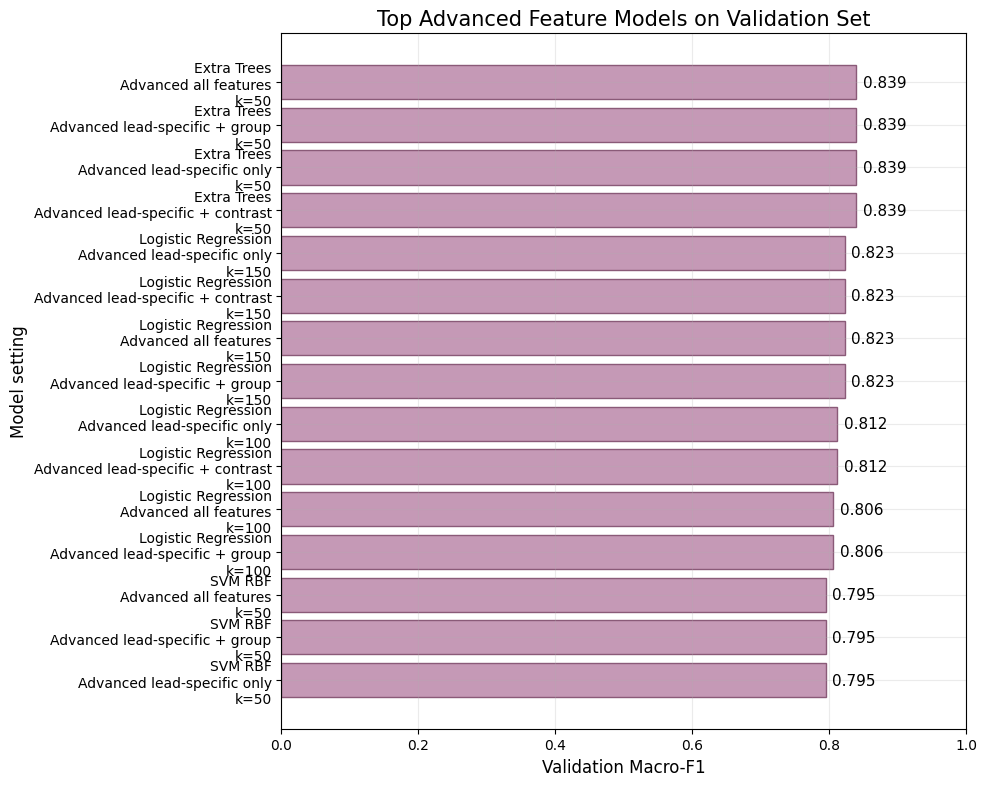

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_top_advanced_validation_models.png


In [21]:
top_val_df = validation_results_df.sort_values(
    ["macro_f1", "roc_auc"],
    ascending=False
).head(15).copy()

top_val_df["display_name"] = (
    top_val_df["model"]
    + "\n"
    + top_val_df["feature_set"]
    + "\nk="
    + top_val_df["k_selected"].astype(str)
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top_val_df["display_name"][::-1],
    top_val_df["macro_f1"][::-1],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Top Advanced Feature Models on Validation Set")
plt.xlabel("Validation Macro-F1")
plt.ylabel("Model setting")
plt.xlim(0, 1)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
fig_path = FIGURE_DIR / "notebook6B_top_advanced_validation_models.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [23]:
best_val_row = validation_results_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

best_feature_set = best_val_row["feature_set"]
best_k = int(best_val_row["k_selected"])
best_model_name = best_val_row["model"]

best_pipe = trained_pipelines[(best_feature_set, best_k, best_model_name)]

print("Best advanced model selected on validation:")
print("Feature set:", best_feature_set)
print("k:", best_k)
print("Model:", best_model_name)

display(best_val_row)

Best advanced model selected on validation:
Feature set: Advanced all features
k: 50
Model: Extra Trees


dataset                             validation
model                              Extra Trees
accuracy                              0.916667
precision_mi                           0.95082
recall_sensitivity_mi                  0.95082
specificity_healthy                   0.727273
f1_mi                                  0.95082
macro_f1                              0.839046
balanced_accuracy                     0.839046
tn                                           8
fp                                           3
fn                                           3
tp                                          58
roc_auc                               0.916542
feature_set              Advanced all features
n_input_features                          2565
k_selected                                  50
Name: 3, dtype: object

In [24]:
# Cell 15
best_cols = feature_sets[best_feature_set]

X_test = test_df[best_cols].astype("float32")
y_test = test_df["mi_detected"]

y_test_pred = best_pipe.predict(X_test)

if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    y_test_score = best_pipe.predict_proba(X_test)[:, 1]
elif hasattr(best_pipe.named_steps["model"], "decision_function"):
    y_test_score = best_pipe.decision_function(X_test)
else:
    y_test_score = None

advanced_test_result = evaluate_binary_classifier(
    y_test,
    y_test_pred,
    y_score=y_test_score,
    model_name=best_model_name,
    dataset_name="test"
)

advanced_test_result["feature_set"] = best_feature_set
advanced_test_result["k_selected"] = best_k
advanced_test_result["n_input_features"] = len(best_cols)

advanced_test_result_df = pd.DataFrame([advanced_test_result])

print("Best advanced model test result:")
display(advanced_test_result_df)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Healthy Control", "MI"],
        zero_division=0
    )
)

Best advanced model test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,k_selected,n_input_features
0,test,Extra Trees,0.897059,0.962264,0.910714,0.833333,0.93578,0.83826,0.872024,10,2,5,51,0.929315,Advanced all features,50,2565



Classification report:
                 precision    recall  f1-score   support

Healthy Control       0.67      0.83      0.74        12
             MI       0.96      0.91      0.94        56

       accuracy                           0.90        68
      macro avg       0.81      0.87      0.84        68
   weighted avg       0.91      0.90      0.90        68



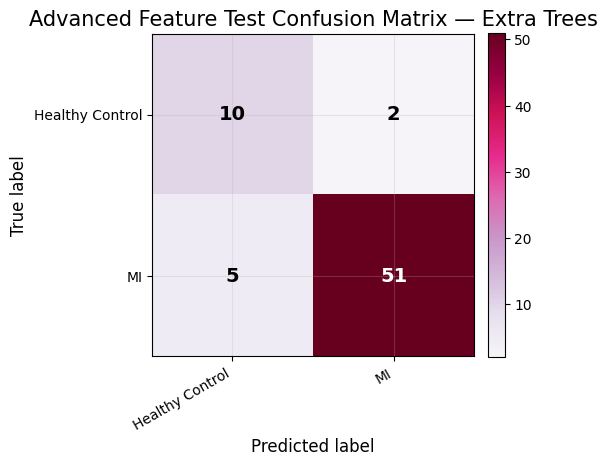

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_best_advanced_test_confusion_matrix.png


In [25]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

fig_path = FIGURE_DIR / "notebook6B_best_advanced_test_confusion_matrix.png"

plot_confusion_matrix_custom(
    cm,
    title=f"Advanced Feature Test Confusion Matrix — {best_model_name}",
    save_path=fig_path
)

print("Saved:", fig_path)

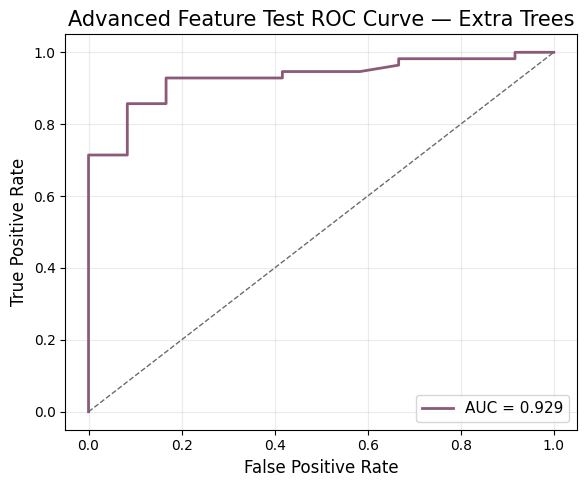

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_best_advanced_test_roc_curve.png


In [26]:
# Cell 17 - ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_score)
auc_value = roc_auc_score(y_test, y_test_score)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    color=PURPLE_DARK,
    linewidth=2,
    label=f"AUC = {auc_value:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=GRAY,
    linewidth=1
)

plt.title(f"Advanced Feature Test ROC Curve — {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6B_best_advanced_test_roc_curve.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [27]:
# Cell 18 - Compare
old_results_df = pd.DataFrame([
    {
        "setting": "Old handcrafted features — SVM RBF default",
        "accuracy": 0.852941,
        "recall_sensitivity_mi": 0.839286,
        "specificity_healthy": 0.916667,
        "macro_f1": 0.795673,
        "roc_auc": 0.937500,
        "tn": 11,
        "fp": 1,
        "fn": 9,
        "tp": 47
    },
    {
        "setting": "Old handcrafted features — recall-priority",
        "accuracy": 0.867647,
        "recall_sensitivity_mi": 0.892857,
        "specificity_healthy": 0.750000,
        "macro_f1": 0.792049,
        "roc_auc": 0.937500,
        "tn": 9,
        "fp": 3,
        "fn": 6,
        "tp": 50
    },
    {
        "setting": "Old patient-level aggregation",
        "accuracy": 0.866667,
        "recall_sensitivity_mi": 0.863636,
        "specificity_healthy": 0.875000,
        "macro_f1": 0.841270,
        "roc_auc": 0.954545,
        "tn": 7,
        "fp": 1,
        "fn": 3,
        "tp": 19
    }
])

advanced_compare_row = {
    "setting": f"Advanced fiducial-inspired features — {best_model_name}",
    "accuracy": advanced_test_result["accuracy"],
    "recall_sensitivity_mi": advanced_test_result["recall_sensitivity_mi"],
    "specificity_healthy": advanced_test_result["specificity_healthy"],
    "macro_f1": advanced_test_result["macro_f1"],
    "roc_auc": advanced_test_result["roc_auc"],
    "tn": advanced_test_result["tn"],
    "fp": advanced_test_result["fp"],
    "fn": advanced_test_result["fn"],
    "tp": advanced_test_result["tp"]
}

comparison_df = pd.concat(
    [
        old_results_df,
        pd.DataFrame([advanced_compare_row])
    ],
    ignore_index=True
)

display(comparison_df)

comparison_path = TABLE_DIR / "notebook6B_advanced_vs_old_detection_results.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8-sig")

print("Saved:", comparison_path)

,setting,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc,tn,fp,fn,tp
0,Old handcrafted features — SVM RBF default,0.852941,0.839286,0.916667,0.795673,0.937500,11,1,9,47
1,Old handcrafted features — recall-priority,0.867647,0.892857,0.750000,0.792049,0.937500,9,3,6,50
2,Old patient-level aggregation,0.866667,0.863636,0.875000,0.841270,0.954545,7,1,3,19
3,Advanced fiducial-inspired features — Extra Trees,0.897059,0.910714,0.833333,0.838260,0.929315,10,2,5,51


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6B_advanced_vs_old_detection_results.csv


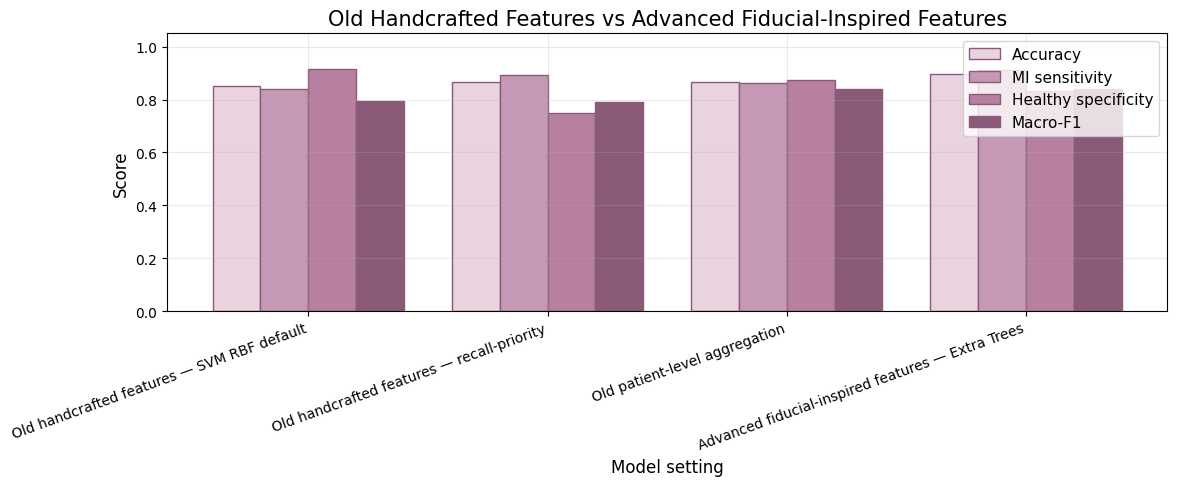

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_old_vs_advanced_feature_comparison.png


In [28]:
plot_df = comparison_df.copy()

x = np.arange(len(plot_df))
width = 0.2

plt.figure(figsize=(12, 5))

plt.bar(
    x - 1.5 * width,
    plot_df["accuracy"],
    width,
    label="Accuracy",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x - 0.5 * width,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 0.5 * width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_MID,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + 1.5 * width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.title("Old Handcrafted Features vs Advanced Fiducial-Inspired Features")
plt.xlabel("Model setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["setting"], rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6B_old_vs_advanced_feature_comparison.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [29]:
selector = best_pipe.named_steps["select"]
selected_mask = selector.get_support()

selected_features = np.array(best_cols)[selected_mask]
selected_scores = selector.scores_[selected_mask]

selected_feature_df = pd.DataFrame({
    "feature": selected_features,
    "anova_f_score": selected_scores
}).sort_values("anova_f_score", ascending=False)

print("Number of selected features:", len(selected_feature_df))
display(selected_feature_df.head(50))

selected_feature_path = TABLE_DIR / "notebook6B_selected_advanced_features.csv"
selected_feature_df.to_csv(selected_feature_path, index=False, encoding="utf-8-sig")

print("Saved:", selected_feature_path)

Number of selected features: 50


,feature,anova_f_score
42,v6_adv_t_abs_amp_min,148.866882
32,v5_adv_t_area_mean,146.412228
26,v5_adv_t_max_amp_median,145.443400
25,v5_adv_t_max_amp_mean,145.232755
31,v5_adv_t_abs_amp_min,143.096557
33,v5_adv_t_area_median,142.962476
10,i_adv_t_polarity_min,140.295796
37,v6_adv_t_max_amp_median,138.603138
43,v6_adv_t_area_mean,138.349283
18,avr_adv_t_abs_amp_min,137.949616


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6B_selected_advanced_features.csv


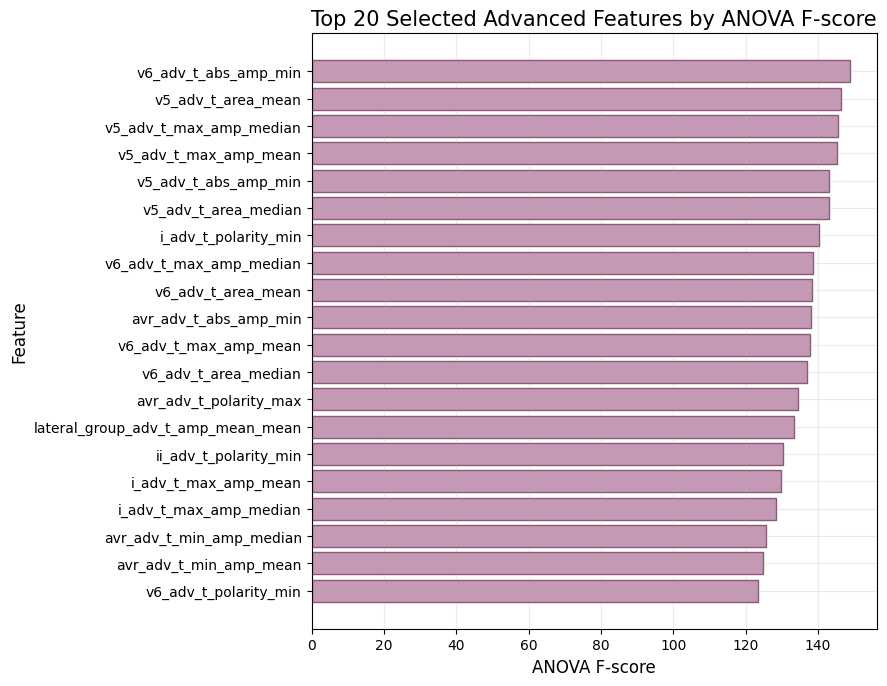

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_top_selected_advanced_features.png


In [30]:
top_features = selected_feature_df.head(20).copy()

plt.figure(figsize=(9, 7))

bars = plt.barh(
    top_features["feature"][::-1],
    top_features["anova_f_score"][::-1],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Top 20 Selected Advanced Features by ANOVA F-score")
plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6B_top_selected_advanced_features.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# Advanced patient-level aggregation

In [31]:
# ============================================================
# Cell 23 — Patient-level aggregation for advanced model
# ============================================================

test_prediction_df = test_df[[
    "patient_id",
    "record_id",
    "mi_detected"
]].copy()

test_prediction_df["y_true"] = y_test.values
test_prediction_df["y_pred"] = y_test_pred

if y_test_score is not None:
    test_prediction_df["mi_score"] = y_test_score
else:
    test_prediction_df["mi_score"] = y_test_pred

display(test_prediction_df.head())

# Patient-level aggregation:
# true label = max label across records of same patient
# score = mean MI score across records
# predicted label = score >= 0.5

patient_level_pred_df = (
    test_prediction_df
    .groupby("patient_id")
    .agg(
        y_true=("y_true", "max"),
        mean_mi_score=("mi_score", "mean"),
        n_records=("record_id", "count")
    )
    .reset_index()
)

patient_level_pred_df["y_pred"] = (
    patient_level_pred_df["mean_mi_score"] >= 0.5
).astype(int)

advanced_patient_result = evaluate_binary_classifier(
    patient_level_pred_df["y_true"],
    patient_level_pred_df["y_pred"],
    y_score=patient_level_pred_df["mean_mi_score"],
    model_name=best_model_name,
    dataset_name="advanced_patient_level_test"
)

advanced_patient_result["feature_set"] = best_feature_set
advanced_patient_result["k_selected"] = best_k

advanced_patient_result_df = pd.DataFrame([advanced_patient_result])

print("Advanced model patient-level test result:")
display(advanced_patient_result_df)

print("\nPatient-level prediction table:")
display(patient_level_pred_df.head())

advanced_patient_result_path = TABLE_DIR / "notebook6B_advanced_patient_level_result.csv"
advanced_patient_result_df.to_csv(
    advanced_patient_result_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", advanced_patient_result_path)

,patient_id,record_id,mi_detected,y_true,y_pred,mi_score
3,patient002,s0015lre,1,1,1,0.998
5,patient004,s0020are,1,1,1,0.998
6,patient004,s0020bre,1,1,1,0.996
19,patient008,s0028lre,1,1,1,0.754
20,patient008,s0037lre,1,1,1,0.824


Advanced model patient-level test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,k_selected
0,advanced_patient_level_test,Extra Trees,0.9,0.913043,0.954545,0.75,0.933333,0.866667,0.852273,6,2,1,21,0.940341,Advanced all features,50



Patient-level prediction table:


,patient_id,y_true,mean_mi_score,n_records,y_pred
0,patient002,1,0.998000,1,1
1,patient004,1,0.997000,2,1
2,patient008,1,0.740667,3,1
3,patient026,1,1.000000,2,1
4,patient035,1,0.958000,4,1


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6B_advanced_patient_level_result.csv


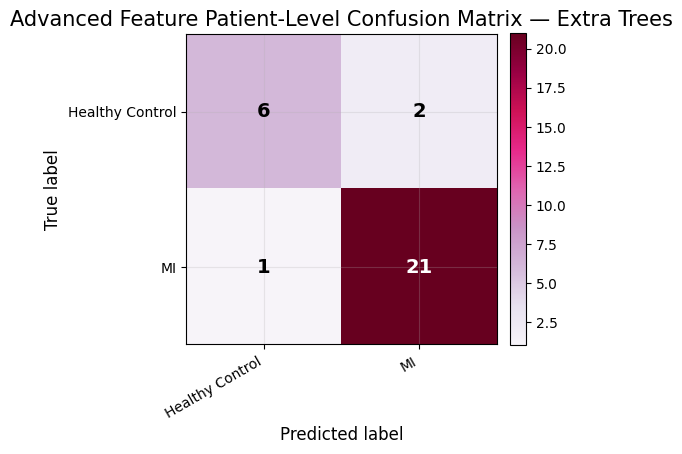

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_advanced_patient_level_confusion_matrix.png


In [32]:
# ============================================================
# Cell 24 — Patient-level confusion matrix for advanced model
# ============================================================

cm_patient = confusion_matrix(
    patient_level_pred_df["y_true"],
    patient_level_pred_df["y_pred"],
    labels=[0, 1]
)

fig_path = FIGURE_DIR / "notebook6B_advanced_patient_level_confusion_matrix.png"

plot_confusion_matrix_custom(
    cm_patient,
    title=f"Advanced Feature Patient-Level Confusion Matrix — {best_model_name}",
    save_path=fig_path
)

print("Saved:", fig_path)

In [33]:
# ============================================================
# Cell 25 — Update old vs advanced comparison with patient-level result
# ============================================================

advanced_patient_compare_row = {
    "setting": f"Advanced patient-level aggregation — {best_model_name}",
    "accuracy": advanced_patient_result["accuracy"],
    "recall_sensitivity_mi": advanced_patient_result["recall_sensitivity_mi"],
    "specificity_healthy": advanced_patient_result["specificity_healthy"],
    "macro_f1": advanced_patient_result["macro_f1"],
    "roc_auc": advanced_patient_result["roc_auc"],
    "tn": advanced_patient_result["tn"],
    "fp": advanced_patient_result["fp"],
    "fn": advanced_patient_result["fn"],
    "tp": advanced_patient_result["tp"]
}

comparison_extended_df = pd.concat(
    [
        comparison_df,
        pd.DataFrame([advanced_patient_compare_row])
    ],
    ignore_index=True
)

display(comparison_extended_df)

comparison_extended_path = TABLE_DIR / "notebook6B_advanced_vs_old_detection_results_extended.csv"
comparison_extended_df.to_csv(
    comparison_extended_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", comparison_extended_path)

,setting,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc,tn,fp,fn,tp
0,Old handcrafted features — SVM RBF default,0.852941,0.839286,0.916667,0.795673,0.937500,11,1,9,47
1,Old handcrafted features — recall-priority,0.867647,0.892857,0.750000,0.792049,0.937500,9,3,6,50
2,Old patient-level aggregation,0.866667,0.863636,0.875000,0.841270,0.954545,7,1,3,19
3,Advanced fiducial-inspired features — Extra Trees,0.897059,0.910714,0.833333,0.838260,0.929315,10,2,5,51
4,Advanced patient-level aggregation — Extra Trees,0.900000,0.954545,0.750000,0.866667,0.940341,6,2,1,21


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6B_advanced_vs_old_detection_results_extended.csv


In [34]:
# ============================================================
# Cell 26 — Patient-wise 5-fold CV for best advanced model
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

cv_data_df = advanced_with_split_df[
    advanced_with_split_df["split"].isin(["train", "validation"])
].copy()

X_cv = cv_data_df[best_cols].astype("float32")
y_cv = cv_data_df["mi_detected"].astype(int)
groups_cv = cv_data_df["patient_id"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold_idx, (train_idx, val_idx) in enumerate(sgkf.split(X_cv, y_cv, groups_cv), start=1):
    print("=" * 80)
    print(f"CV fold {fold_idx}")

    X_train_cv = X_cv.iloc[train_idx]
    y_train_cv = y_cv.iloc[train_idx]

    X_val_cv = X_cv.iloc[val_idx]
    y_val_cv = y_cv.iloc[val_idx]

    model_clone = clone(models[best_model_name])

    cv_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=best_k)),
        ("model", model_clone)
    ])

    cv_pipe.fit(X_train_cv, y_train_cv)

    y_val_pred_cv = cv_pipe.predict(X_val_cv)

    if hasattr(cv_pipe.named_steps["model"], "predict_proba"):
        y_val_score_cv = cv_pipe.predict_proba(X_val_cv)[:, 1]
    elif hasattr(cv_pipe.named_steps["model"], "decision_function"):
        y_val_score_cv = cv_pipe.decision_function(X_val_cv)
    else:
        y_val_score_cv = None

    fold_result = evaluate_binary_classifier(
        y_val_cv,
        y_val_pred_cv,
        y_score=y_val_score_cv,
        model_name=best_model_name,
        dataset_name=f"cv_fold_{fold_idx}"
    )

    fold_result["fold"] = fold_idx
    fold_result["n_train_records"] = len(train_idx)
    fold_result["n_val_records"] = len(val_idx)
    fold_result["n_train_patients"] = cv_data_df.iloc[train_idx]["patient_id"].nunique()
    fold_result["n_val_patients"] = cv_data_df.iloc[val_idx]["patient_id"].nunique()

    cv_results.append(fold_result)

advanced_cv_results_df = pd.DataFrame(cv_results)

display(advanced_cv_results_df)

advanced_cv_summary_df = (
    advanced_cv_results_df[
        [
            "accuracy",
            "precision_mi",
            "recall_sensitivity_mi",
            "specificity_healthy",
            "f1_mi",
            "macro_f1",
            "balanced_accuracy",
            "roc_auc"
        ]
    ]
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(advanced_cv_summary_df)

advanced_cv_results_path = TABLE_DIR / "notebook6B_advanced_cv_fold_results.csv"
advanced_cv_summary_path = TABLE_DIR / "notebook6B_advanced_cv_summary.csv"

advanced_cv_results_df.to_csv(
    advanced_cv_results_path,
    index=False,
    encoding="utf-8-sig"
)

advanced_cv_summary_df.to_csv(
    advanced_cv_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", advanced_cv_results_path)
print("Saved:", advanced_cv_summary_path)

CV fold 1
CV fold 2
CV fold 3
CV fold 4
CV fold 5


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,fold,n_train_records,n_val_records,n_train_patients,n_val_patients
0,cv_fold_1,Extra Trees,0.881579,0.885714,0.984127,0.384615,0.932331,0.729323,0.684371,5,8,1,62,0.902320,1,304,76,137,33
1,cv_fold_2,Extra Trees,0.868421,0.906250,0.935484,0.571429,0.920635,0.768010,0.753456,8,6,4,58,0.928571,2,304,76,136,34
2,cv_fold_3,Extra Trees,0.881579,0.934426,0.919355,0.714286,0.926829,0.808242,0.816820,10,4,5,57,0.879032,3,304,76,136,34
3,cv_fold_4,Extra Trees,0.894737,0.936508,0.936508,0.692308,0.936508,0.814408,0.814408,9,4,4,59,0.947497,4,304,76,135,35
4,cv_fold_5,Extra Trees,0.907895,0.936508,0.951613,0.714286,0.944000,0.842370,0.832949,10,4,3,59,0.949885,5,304,76,136,34


,metric,mean,std
0,accuracy,0.886842,0.015002
1,precision_mi,0.919881,0.023009
2,recall_sensitivity_mi,0.945417,0.024465
3,specificity_healthy,0.615385,0.142009
4,f1_mi,0.932061,0.008949
5,macro_f1,0.792471,0.044175
6,balanced_accuracy,0.780401,0.061628
7,roc_auc,0.921461,0.030426


Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6B_advanced_cv_fold_results.csv
Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook6B_advanced_cv_summary.csv


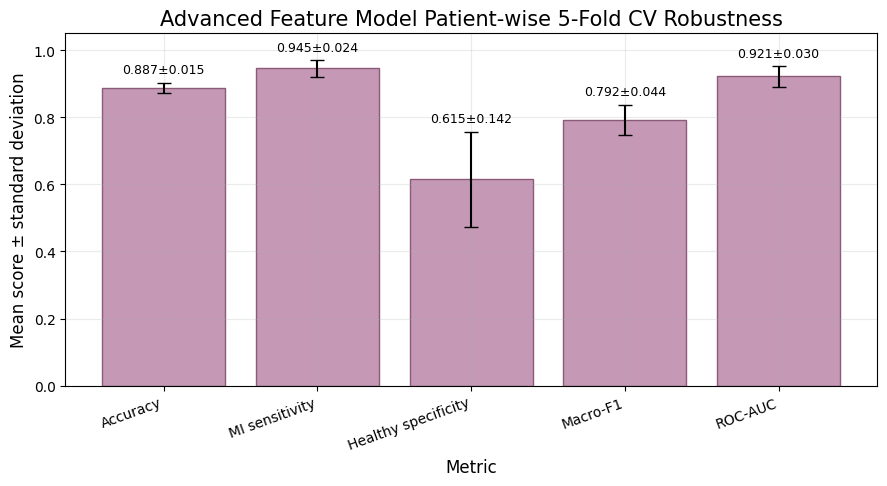

Saved: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook6B_advanced_cv_robustness.png


In [35]:
# ============================================================
# Cell 27 — Plot advanced CV robustness
# ============================================================

plot_cv_df = advanced_cv_summary_df[
    advanced_cv_summary_df["metric"].isin([
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "roc_auc"
    ])
].copy()

metric_name_map = {
    "accuracy": "Accuracy",
    "recall_sensitivity_mi": "MI sensitivity",
    "specificity_healthy": "Healthy specificity",
    "macro_f1": "Macro-F1",
    "roc_auc": "ROC-AUC"
}

plot_cv_df["metric_display"] = plot_cv_df["metric"].map(metric_name_map)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_cv_df["metric_display"],
    plot_cv_df["mean"],
    yerr=plot_cv_df["std"],
    capsize=5,
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Advanced Feature Model Patient-wise 5-Fold CV Robustness")
plt.xlabel("Metric")
plt.ylabel("Mean score ± standard deviation")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")

for i, row in plot_cv_df.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["mean"] + row["std"] + 0.02,
        f"{row['mean']:.3f}±{row['std']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook6B_advanced_cv_robustness.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)